# Batched Layout Optimisation of a Transmon with Optuna

This notebook turns the single-point Palace eigenmode workflow of
{doc}`palace_eigenmode_qubit_resonator` into a design loop. A transmon's
capacitance pads are swept against three objectives at once:

1. **Land the linearised qubit eigenfrequency** near a target. A physical
   transition target needs an anharmonic correction after this solve.
2. **Maximise the substrate-limited quality factor** $Q$ from the same solve.
3. **Minimise the pad footprint**, which is what the chip pays in real estate
   and what a larger qubit spends on coupling and crosstalk.

All three come out of one 3-D eigenmode solve plus the geometry that produced
it, so every trial is an independent Palace run. The default driver submits
individual Slurm jobs; a [Ray](https://docs.ray.io/) backend is optional.
[Optuna](https://optuna.readthedocs.io/) proposes geometries with a
multi-objective (NSGA-II) sampler.

The loss side follows {cite:p}`Savola2023`. The energy participation ratios
$p_i$ of the lossy domains, weighted by their loss tangents, give the
dielectric quality factor

$$
Q_\mathrm{TLS} = \left(\sum_i p_i \tan\delta_i\right)^{-1},
\qquad
T_1^\mathrm{TLS} \approx \frac{Q_\mathrm{TLS}}{2\pi f_\mathrm{lin}} .
$$

The `f_linear` result is the electromagnetic mode, not the anharmonic
0-1 transition. $T_1$ is shown as a derived check rather than
optimised separately: its
frequency dependence would otherwise make a low-frequency device look
attractive even when its field loss is unchanged. The Pareto frontier keeps
frequency error, $Q$ and footprint visible as separate choices.

::::{admonition} Required extras
:class: tip

This notebook needs the `models` extra for gsim and Optuna. The Ray backend,
if you use it, needs `ray` as well:

```bash
uv add "qpdk[models]"
# or, from a checkout of this repository:
uv sync --extra models          # add --extra ray for the Ray backend
# or with pip:
pip install "qpdk[models]"
```

The optimisation additionally needs the Palace solver, which is external to
qpdk and normally runs on an HPC cluster. Those cells are written out but not
executed when the notebook is rendered; the trial table is embedded so the
analysis runs anywhere.

See the {ref}`extras reference <notebook-extras>` for what each extra installs.
::::

::::{note}
The saved results below were generated on Aalto Triton with meshing on
compute nodes and Palace inside an Apptainer image. The
{ref}`launcher <slurm-launcher>` below shows how to run the same workflow.
::::

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[models] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])

In [2]:
import io
import os
import sys
from pathlib import Path
from typing import Any

import matplotlib

# The same source file is the cluster driver, where there is no display and a
# blocking figure would hang the batch. Rendering inside a kernel keeps the
# interactive backend so the figures appear inline.
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd

from qpdk import logger
from qpdk.logger import PLAIN_FORMAT, configure_logger
from qpdk.simulation import SlurmCluster
from qpdk.simulation.palace_run import (
    domain_loss_tangents,
    evaluate_simulation,
    solve,
)
from qpdk.simulation.study import RayRunner, SlurmRunner, run_study
from qpdk.simulation.transmon_sweep import LAYOUT_GRID_UM, Layout, build_simulation

for style in (Path("docs/qpdk.mplstyle"), Path("../docs/qpdk.mplstyle"), "qpdk"):
    try:
        plt.style.use(style)
        break
    except OSError:
        continue

if "ipykernel" in sys.modules:
    import matplotlib_inline

    # Raster outputs avoid Matplotlib SVG links that docs link checkers follow.
    matplotlib_inline.backend_inline.set_matplotlib_formats("png")

## The device and its knobs

The device is the {func}`~qpdk.cells.double_pad_transmon_with_bbox` cell: two
rectangular capacitor pads facing each other across a narrow gap, with the
Josephson junction in that gap. Three layout parameters set both observables:

- **pad width** $w$: the pad extent along the junction gap, which sets
  how much pad edge sits close to the opposite pad.
- **pad height** $h$: the pad extent perpendicular to the gap. This is
  the parameter {cite:p}`Savola2023` found most effective for coherence, since
  it adds shunt capacitance without crowding field into the gap.
- **pad gap** $g$: the island-island separation the junction bridges,
  and the strongest single-parameter lever on the frequency.

The frequency follows from the LC circuit the solve implies,
$f_\mathrm{lin} \approx 1/(2\pi\sqrt{L_J C_\Sigma})$, with the junction held at a
fixed $L_J = 10$ nH. That linearisation is what makes a purely
electromagnetic solve informative about the qubit, and it is the same one the
{doc}`palace_eigenmode_qubit_resonator` notebook uses.

The layout and evaluator live in {mod}`qpdk.simulation.transmon_sweep` so a
trial job can import the same code used here.

In [3]:
PAD_WIDTH_RANGE = (80.0, 420.0)  # µm, along the junction gap
PAD_HEIGHT_RANGE = (150.0, 650.0)  # µm, perpendicular to it
PAD_GAP_RANGE = (10.0, 160.0)  # µm, island-island separation

# A fixed inductor, so the geometry moves the linearised frequency through capacitance.
L_JUNCTION = 10e-9  # H
F_TARGET = 4.5e9  # Hz, target linearised mode; the physical transition is lower
# How close to the target counts as on-target when picking a geometry.
TOLERANCE_BAND = 0.02
# Accept small Q differences when choosing a smaller pad footprint.
Q_SLACK = 0.01

# The study size follows the allocation rather than the other way round, so the
# Slurm launcher at the end of the notebook sets these from the job request.
# One switch for every cell that needs a solver, so a half-set value cannot
# run the demos and then silently skip the study.
RUN_OPTIMIZATION = os.environ.get("QPDK_RUN_OPTIMIZATION") == "1"
RUN_DEMO_SOLVE = os.environ.get("QPDK_RUN_DEMO_SOLVE") == "1"
if RUN_OPTIMIZATION:
    # The driver's stdout is a Slurm .out file someone will `tail -f`, not a
    # terminal, so drop the colour escapes and the decoration.
    configure_logger(log_format=PLAIN_FORMAT, colorize=False)
MAX_IN_FLIGHT = int(os.environ.get("QPDK_MAX_IN_FLIGHT") or 6)  # trials at once
N_TRIALS = int(os.environ.get("QPDK_N_TRIALS") or 150)  # total trials

## From a layout to a simulation directory

{func}`~qpdk.simulation.transmon_sweep.build_simulation` wraps the three steps
repeated for each geometry:

1. Lay the cell out and convert the PDK's subtractive etch masks into explicit
   conductor, substrate and vacuum regions ({func}`~qpdk.simulation.to_fem_regions`).
2. Give each region a material and a z-extent through the qpdk single-chip
   layer stack ({func}`~qpdk.simulation.single_chip_stack`).
3. Configure the lumped junction port and the eigenmode search, then mesh.

Two details there are easy to get wrong, and both fail quietly:

- **The junction port has to span the pad gap.** The cell's `junction` port
  carries the junction component's own orientation, which is not the axis the
  pads face along. A port on the wrong axis still solves, it just returns modes
  with no junction energy, and the mode identification below would then pick up
  a spurious mode.
- **Domain energy postprocessing is off by default.** gsim writes an empty
  `Domains.Postprocessing.Energy` list, so {func}`~qpdk.simulation.palace_run.add_domain_energy_postprocessing`
  adds it after the config is written. Without it nothing
  reports where the field is sitting, and the loss budget has no inputs.

The result is a self-contained directory. `config.json` plus `palace.msh` is
everything a Palace binary needs, which is what lets a Ray worker on some
other node pick a trial up with no shared state beyond the filesystem.

In [4]:
demo_layout = Layout(pad_width=250.0, pad_height=400.0, pad_gap=15.0)
demo_dir = Path("build/palace_optimization_demo")
# Meshing needs Gmsh and a large allocation, so the demo runs separately from
# the one-core sweep driver.
if RUN_DEMO_SOLVE:
    build_simulation(demo_layout, demo_dir)
    logger.info(f"wrote {demo_dir}")

## Running Palace

Palace is invoked as a subprocess against that directory, so how it is
launched is a site detail rather than a property of the workflow:
{func}`~qpdk.simulation.palace_run.palace_command` reads the arrangement from
the environment, covering a `palace` on `PATH`, an Apptainer image on a compute
node, and a wrapper command for the awkward cases.

## Reading a solve back into physics

Palace writes three tables per solve, and each carries a piece of the answer:

- `eig.csv`: complex eigenfrequencies and their raw quality factors. The
  reported sweep objective instead combines dielectric participation and
  loss tangents, which is more stable at this mesh resolution.
- `port-EPR.csv`: each lumped port's energy participation, which is what
  identifies the qubit mode among the packaging and ground-plane modes the
  solve also returns. The rule is the **lowest** mode the junction takes part
  in, and picking the largest participation instead is a trap: a higher-order
  mode can carry marginally more junction energy than the fundamental, and
  that near-tie silently returns harmonics at several times the qubit
  frequency.
- `domain-E.csv`: the electric energy in each domain, hence $p_i$
  directly. This is what makes the loss budget legible.

In [5]:
# Run the demo inside an allocation sized like one trial before launching a sweep.
if RUN_DEMO_SOLVE:
    solve(demo_dir, ranks=int(os.environ.get("QPDK_SOLVER_CORES") or 24))
    demo_result = evaluate_simulation(demo_dir)
    logger.info(
        f"demo layout: f_lin = {demo_result['f_linear'] / 1e9:.4f} GHz, "
        f"T1 = {demo_result['T1'] * 1e6:.2f} µs, "
        f"Q = {demo_result['quality_factor']:.3e}"
    )

### The loss budget, and what is missing from it

The stack has two dielectric domains: lossless vacuum and silicon with qpdk's
low-temperature loss tangent ($\tan\delta_\mathrm{Si} = 2.7\times10^{-6}$).
The objective $Q_\mathrm{diel} =
\left(\sum_i p_i\tan\delta_i\right)^{-1}$ uses the resolved dielectric loss.
The raw complex-eigenfrequency $Q$ is retained as a diagnostic; the two can
differ at finite resolution.

The caveat it also makes visible is the interesting one. The interfaces that
dominate TLS loss in a real chip, metal-air, metal-substrate and
substrate-air, are nanometres thick and are not resolved by a mesh built for a
millimetre-scale layout. {cite:p}`Savola2023` treats them in 2-D cross-sections
where the layers can be meshed explicitly, and finds the metal-air interface
alone carrying roughly 90 % of the surface participation. So the `Q` here is
the *substrate-limited* one, and since
$Q_\mathrm{TLS} = (\sum_i p_i \tan\delta_i)^{-1}$ it is an upper bound:
every interface the model cannot see adds a term to that sum and can only
lower it. The $Q$ and $T_1$ below are therefore optimistic for a real chip.

It is worth putting a number on how optimistic. The silicon loss tangent here
is qpdk's measured $2.7\times10^{-6}$, so the substrate term is
$p_\mathrm{sub}\tan\delta_\mathrm{sub} \approx 2.5\times10^{-6}$. The
interface budget {cite:p}`Savola2023` measures for a comparable niobium-on-
silicon process, with the metal-air, metal-substrate and substrate-air layers
included, is $\delta_\mathrm{interfaces} \approx 1.0\times10^{-6}$ to
$5.5\times10^{-6}$. Adding that to the substrate term rather than
assuming it away puts the total loss 1.4x to 3.2x higher, and $Q$ in the
$1\times10^5$ to $3\times10^5$ range instead of $4\times10^5$.
Omitted interface losses can also change the ordering of candidate layouts.

With only bulk loss in the model, the $Q$ spread is expected to be much smaller
than in a design with surface TLS participation. The latter responds to metal
edges and is exactly what this mesh does not resolve.

In [6]:
if RUN_DEMO_SOLVE:
    tangents = domain_loss_tangents(demo_dir)
    budget = sum(
        demo_result[f"participation_domain{index}"] * tangent
        for index, tangent in tangents.items()
    )
    logger.info(
        f"1/Q from participations {budget:.4e}; "
        f"raw eigenmode 1/Q {1 / demo_result['eigenmode_quality_factor']:.4e}"
    )

## Checking that the mode is real

A solve that converges is not the same as a solve that found the device. The
failure to watch for is a lumped port that does not actually touch the metal it
is supposed to bridge: the mesh still validates, the solve still converges, and
every number that comes back is an artifact of the port's own local
capacitance. Two checks separate the two cases, and both are cheap enough to
run before trusting a sweep.

**Port connectivity.** The port's surface has to share mesh nodes with the
conductor. Below, the port rectangle shares four nodes with the metal, which is
what a healthy transmon port looks like; a broken one shares none.

```python
import gmsh

gmsh.initialize()
gmsh.open("palace.msh")
# {'P1': 4} -> the junction port shares 4 nodes with the metal
```

**Inductance scaling.** The qubit mode is an LC mode of the junction, so
doubling the junction inductance should move it by approximately
$1/\sqrt{2}$ and leave its participation nearly unchanged. A packaging or
ground-plane mode does not care about the junction at all. Solving the same
geometry twice on the cluster gives

| $L_J$ | $f_\mathrm{lin}$ (GHz) | junction participation |
| --- | --- | --- |
| 10 nH | 1.901119 | 0.124025 |
| 20 nH | 1.344503 | 0.124063 |

a ratio of 0.70722 against the expected 0.70711, or 0.016 % off, with the
participation nearly unchanged. That is the mode this notebook is
optimising, not a port artifact.

```python
for factor in (1.0, 2.0):
    build_simulation(geometry, sim_dir, junction_inductance=10e-9 * factor, refined_mesh_size=0.75)
    solve(sim_dir, ranks=8)
    print(evaluate_simulation(sim_dir)["f_linear"])
```

### Mesh sensitivity

For 250 × 400 µm pads with a 15 µm gap, 500 µm each of silicon and vacuum,
and a 250 µm outer margin, second-order elements give:

| conductor mesh size (µm) | linearised mode (GHz) | silicon $p_e$ | dielectric $Q$ |
| ---: | ---: | ---: | ---: |
| 1.50 | 2.021695 | 0.919694 | 402710 |
| 1.00 | 1.949343 | 0.919667 | 402722 |
| 0.75 | 1.901119 | 0.919674 | 402719 |
| 0.50 | 1.836645 | 0.919667 | 402722 |
| 0.35 | 1.787955 | 0.919672 | 402720 |
| 0.25 | 1.745593 | 0.919630 | 402739 |

These checks and the 150-trial sweep use gsim's coarse bulk-mesh preset.
The silicon participation changes by less than $7\times10^{-5}$ and its
dielectric $Q$ by 0.007% across these meshes. The linearised frequency still
shifts by 2.4% between the two finest meshes, so the absolute frequency and
target-band selection in the 0.35 µm sweep are resolution-limited. Small
differences in $Q$ between candidate layouts also need a finer check before
fabrication. The saved sweep shows the workflow and broad tradeoffs; a final
mask choice needs a finer follow-up solve.
A third-order solve at 1.00 µm gives 1.843816 GHz and $p_{e,\mathrm{Si}}=0.919682$;
its frequency is 0.39% above the second-order 0.50 µm value. That cross-check
does not remove the finer-mesh frequency shift.
For on-target trial 50 at 0.35 µm, raising Palace's linear-solver `MaxIts`
from 1 to 3 on the same mesh changes frequency by 0.032 MHz and silicon
participation by $2.4\times10^{-12}$. Its raw eigenmode $Q$ moves from
$3.66\times10^5$ to $4.03\times10^5$, so the sweep uses the stable
participation-derived dielectric $Q$ instead.
The embedded sweep used direct MUMPS at 0.35 µm. Its most memory-hungry trial
peaked at 157.5 GB on one node. The runnable recipe below uses two-level
multigrid with an exact MUMPS coarse solve. On that same trial and mesh, eight
MPI ranks across two nodes used 53.5 GB total; the frequency changed by
0.051 MHz and silicon electric-energy participation by $3.5\times10^{-9}$.
Its raw complex-frequency $Q$ is less stable, so the dielectric $Q$ remains
the study objective. Finer mesh checks need their own resource sizing.

In [7]:
# The site settings live here, and every one of them can be overridden from the
# environment so that a driver script can point the notebook at a real cluster
# without editing it. The defaults are placeholders.
def site(name: str, default: str) -> str:
    """Return a site setting, letting the environment override the default."""
    return os.environ.get(f"QPDK_{name.upper()}") or default


DEFAULT_SETUP = """
module load python 2>/dev/null || true
export UV_CACHE_DIR="$QPDK_SCRATCH/uv-cache"
export UV_PYTHON_INSTALL_DIR="$QPDK_SCRATCH/uv-python"
export PATH="$PWD/.venv/bin:$HOME/.local/bin:$PATH"
"""

# The Palace image, as a compute node sees it. Passed to the trial processes
# through the environment rather than the allocation.
PALACE_SIF = site("sif", "/path/to/palace.sif")

cluster = SlurmCluster(
    # Name every partition the job can run on, not just the fastest: Slurm
    # starts the job wherever it can begin earliest, which usually beats
    # waiting on one busy partition.
    partition=site("partition", "batch"),
    # A shared filesystem visible from every node, where the jobs run and the
    # trial directories are written.
    scratch=site("scratch", "/scratch/$USER/palace-optimization"),
    # Load whatever the site needs before the solver starts. Two things this
    # usually has to cover: a cluster's packaged Python is often older than
    # qpdk's floor, so let uv fetch its own interpreter, and home directories
    # are small and shared, so the caches belong on scratch.
    setup=site("setup", DEFAULT_SETUP),
    # The two-node screening recipe was checked on the largest direct trial.
    solver_cores=int(site("solver_cores", "8")),
    trial_nodes=int(site("trial_nodes", "2")),
    mem_per_task=site("mem_per_task", "32G"),
    time_limit=site("time_limit", "02:00:00"),
    # Only the Ray arrangement uses these: they size the one allocation it
    # hosts the cluster in. One job per trial is sized on its own instead.
    nodes=int(site("nodes", "2")),
    cores_per_node=int(site("cores_per_node", "8")),
    mem_per_node=site("mem_per_node", "64G"),
    job_name=site("job_name", "qpdk-opt"),
    log_dir=site("log_dir", "slurm-logs"),
    # Empty means "do not emit --account"; many sites have exactly one usable
    # account and reject an explicit one.
    account=site("account", "") or None,
    driver_time_limit=site("driver_time_limit", "24:00:00"),
)

## Running the study

A trial is independent of every other, so the study is just: ask Optuna for a
geometry, evaluate it somewhere, tell Optuna what came back. Only the middle
step depends on where the compute is, and that is the one piece worth
swapping.

{func}`~qpdk.simulation.study.run_study` owns the loop, and a *runner* owns
the "somewhere". Two come with qpdk, differing only in where a trial lands:

- {class}`~qpdk.simulation.study.SlurmRunner` submits one job per trial. The
  MPI ranks split across two nodes with a modest memory request on each.
- {class}`~qpdk.simulation.study.RayRunner` dispatches a Ray task per trial,
  for when the study already owns an allocation.
  Each Ray task keeps its eight solver ranks on one node, so that alternative
  retains a 64 GiB per-node request. The Slurm runner above splits a trial
  across two nodes at 32 GiB each.

Either way the trial runs in another process, so the runner names its
evaluator as `module:function`. The default is
{func}`~qpdk.simulation.transmon_sweep.evaluate_layout`, which the worker can
import directly from qpdk.

What it deliberately does *not* do is evaluate fixed batches. A batch can only
advance when its slowest member finishes, so a wave of twelve solves leaves
most of its allocation idle waiting for one large mesh, and the sampler learns
nothing until the whole wave lands. Instead a fixed number of trials stays in
flight: each result is told to the sampler as it arrives, and its slot is
refilled immediately. `max_in_flight` is the only concurrency knob, and it
belongs to the study rather than to the scheduler.

In [8]:
RUN_ROOT = (
    Path(os.path.expandvars(site("scratch", "build"))) / "palace_optimization_trials"
)


def suggest_layout(trial: optuna.Trial) -> None:
    """Ask Optuna for a candidate geometry, recording it on the trial.

    Suggestions land on the layout grid, so a trial's recorded parameters are
    exactly the geometry that was simulated.
    """
    for name, (low, high) in (
        ("pad_width", PAD_WIDTH_RANGE),
        ("pad_height", PAD_HEIGHT_RANGE),
        ("pad_gap", PAD_GAP_RANGE),
    ):
        trial.suggest_float(name, low, high, step=LAYOUT_GRID_UM)


def objectives(row: dict[str, Any]) -> list[float]:
    """Map one solved trial to the three values the study is ranking.

    Args:
        row: A result row from ``evaluate_layout``.

    Returns:
        Relative frequency error, substrate-limited quality factor, and pad footprint.
    """
    return [
        abs(row["f_linear"] - F_TARGET) / F_TARGET,
        row["quality_factor"],
        row["footprint_mm2"],
    ]


def make_study() -> optuna.Study:
    """Return the multi-objective study this sweep optimises.

    Returns:
        A study ranking frequency error, quality factor and footprint together.
    """
    return optuna.create_study(
        study_name="transmon-layout",
        # Frequency error, then substrate-limited Q, then footprint.
        directions=["minimize", "maximize", "minimize"],
        # NSGA-II keeps a population of non-dominated trials instead of
        # collapsing the objectives into one score.
        sampler=optuna.samplers.NSGAIISampler(seed=0),
    )


# Where the worker imports `evaluate_layout` from, on the node it lands on.
EVALUATOR = os.environ.get(
    "QPDK_EVALUATOR", "qpdk.simulation.transmon_sweep:evaluate_layout"
)


def make_runner() -> SlurmRunner | RayRunner:
    """Return the runner the environment selects.

    Returns:
        A Ray runner when ``QPDK_EXECUTOR=ray``, otherwise a Slurm one.
    """
    if os.environ.get("QPDK_EXECUTOR") == "ray":
        return RayRunner(
            run_root=RUN_ROOT, ranks=cluster.solver_cores, evaluator=EVALUATOR
        )
    return SlurmRunner(
        cluster=cluster,
        run_root=RUN_ROOT,
        ranks=cluster.solver_cores,
        evaluator=EVALUATOR,
        timeout=6000.0,
    )

## Results

The study cell above is skipped when the notebook is rendered; the table it
produced is embedded instead, so everything below runs without a solver.

In [9]:
# Palace sweep results, embedded so the analysis runs without the solver:
# one row per successful trial, with geometry, objectives, and loss diagnostics.
TRIALS_CSV = """\
trial,pad_width,pad_height,pad_gap,f_linear,T1,quality_factor,eigenmode_quality_factor,junction_participation,footprint_mm2,participation_domain1,participation_domain2
0,266.6,507.6,100.42,3797003092.293,1.6878723318291066e-05,402680.3276634939,430703.4749415,0.4451640916689,0.27065232,0.9197627619889,0.08023723801114
1,265.26,361.83000000000004,106.89,4409049860.750999,1.453543428331894e-05,402673.35250667564,429006.1304302,0.459209235227,0.1919580516,0.9197786942314,0.08022130576858
2,228.78,595.89,154.55,4263175014.394,1.5032891385688452e-05,402675.81832228595,412231.8894134,0.5521997818113,0.27265542839999996,0.9197730618975,0.08022693810253
3,210.37,545.87,89.33,3709141759.7860003,1.7278900371890447e-05,402688.6610462076,371064.4631691,0.4163781805012,0.2296693438,0.9197437280904,0.08025627190956
4,273.14,612.8,20.65,1726031389.174,3.713371765522912e-05,402714.24201158894,405055.8993509,0.1434353849046,0.33476038399999997,0.9196853046973,0.08031469530267
5,109.62,160.1,134.9,7825868101.811,8.188935842262273e-06,402661.2717817656,326478.2154735,0.5104544555907,0.035100324,0.9198062896178,0.08019371038221
6,344.58,585.01,156.8,3943529532.769,1.6251041694138357e-05,402667.1218253758,404442.8962496,0.5556425622672,0.4031654915999999,0.9197929264535,0.08020707354651
7,351.72,380.74,127.08,4285259121.6839995,1.4955344044855437e-05,402673.79222482204,366651.6346567,0.502981282107,0.2678277456,0.9197776898368,0.08022231016322
8,120.21000000000001,469.96,31.5,2754449840.58,2.3269545838012498e-05,402719.4856704795,396183.9614404,0.2011075506503,0.11298778320000001,0.919673329821,0.08032667017896
9,401.19,410.92,72.2,3307417191.92,1.9378041613285422e-05,402697.31327487185,399185.573734,0.3654731142989,0.32971398960000003,0.919723966764,0.08027603323597
10,169.95,537.12,78.42,3699433449.9249997,1.7324801358217104e-05,402701.596398976,403555.8530322,0.3845587103452,0.182567088,0.9197141846029,0.08028581539708
11,273.27,159.39,102.65,5616934936.861,1.1409427983231092e-05,402664.3056358437,414957.5862001,0.4450482332067,0.08711301059999998,0.9197993593833,0.08020064061673
12,288.11,458.47,151.57,4448186362.0529995,1.4407060652380758e-05,402659.7570028844,370903.5132115,0.5468594636206,0.26417958340000003,0.9198097498671,0.08019025013293
13,311.82,329.75,75.55,3858977850.949,1.6607660950271296e-05,402680.52325690625,420943.4495571,0.3747290533163,0.20564529,0.9197623152339,0.08023768476611
14,317.20000000000005,180.11,110.02,5312388469.606999,1.2063272610421117e-05,402656.6129606468,443419.990726,0.4636210487482,0.11426178400000003,0.9198169319687,0.08018306803131
15,308.02,255.19,29.34,2821583645.1070004,2.2715017818156918e-05,402703.9407567696,434633.2777456,0.1895959979307,0.15720724760000002,0.9197088304484,0.08029116955155
16,187.24,331.85,95.53,4739054852.601,1.3523955218901769e-05,402694.1567846204,425672.5179153,0.4299678637463,0.124271188,0.9197311759566,0.08026882404336
17,229.12,644.19,25.3,1925094404.6430001,3.329397974735234e-05,402714.8191238882,400376.0049502,0.169524327645,0.2951936256,0.9196839867381,0.08031601326188
18,151.01999999999998,230.65,107.97,5938837429.647,1.0791854400265826e-05,402696.0621046716,394125.7310305,0.4572106781451,0.06966552599999999,0.9197268243316,0.08027317566844
19,166.12,383.15999999999997,46.660000000000004,3410630918.1540003,1.8791582504653738e-05,402696.5863976206,399408.8999774,0.2699248234288,0.1273010784,0.9197256268884,0.08027437311162
20,134.05,205.18,108.45,6376554845.281,1.0050361923026178e-05,402668.5114021051,341359.035077,0.4568403093784,0.05500875800000001,0.9197897523219,0.08021024767808
21,126.98,248.29000000000002,65.31,4957409554.868,1.2928174202728328e-05,402690.9442743351,379823.0988825,0.3363042396307,0.06305572840000001,0.9197385132109,0.08026148678908
22,359.14,198.55,135.7,5313539757.431,1.206049668638884e-05,402651.19884143444,368587.8197555,0.5170595291024,0.142614494,0.9198292999898,0.0801707000102
23,112.67,638.23,80.3,3749790697.026,1.7092172925061648e-05,402702.3589795095,407883.2952965,0.39023109682,0.1438187482,0.9197124429788,0.08028755702117
24,412.1,452.42,120.89,3823588838.039,1.676133757988741e-05,402679.6908472816,405158.2018842,0.4911592926159,0.37288456400000003,0.9197642165441,0.08023578345592
25,93.32,291.4,28.03,3338468310.8980002,1.9198138225923608e-05,402704.2757853828,403132.0873365,0.1806909045879,0.05438689599999999,0.9197080652994,0.08029193470057
26,180.69,209.36,57.7,4621679490.686,1.386747231651125e-05,402695.70738918276,454356.109016,0.3097004100511,0.07565851679999999,0.9197276344752,0.08027236552477
27,220.85,182.07,113.87,5931023775.11,1.0805216414430763e-05,402664.1850023767,59482.37570357,0.4708567953774,0.08042031899999999,0.9197996349444,0.08020036505559
28,272.65,282.69,88.49,4462908640.495,1.4360325425746381e-05,402681.934835533,364116.0348959,0.4114612649803,0.154150857,0.9197590910594,0.08024090894059
29,111.94,437.97,149.4,5543581692.522,1.1560720608896508e-05,402675.51779925846,353555.075862,0.5422604952169,0.0980527236,0.9197737483385,0.08022625166148
30,188.31,483.71,29.77,2441558954.868,2.6252236746836662e-05,402729.4563986295,401745.3936965,0.1924339153261,0.18217486019999998,0.9196505606577,0.08034943934229
31,323.55,294.70000000000005,37.480000000000004,2968867143.581,2.1588663265697963e-05,402713.6813863033,384909.0263197,0.2303320964041,0.19070037000000004,0.9196865850085,0.0803134149915
32,279.42,160.05,134.34,6059920960.589001,1.0574858638547867e-05,402644.1546462102,390451.0606427,0.5133687776889,0.08944234200000001,0.9198453922566,0.08015460774336
33,81.59,488.91,50.5,3642477714.4220004,1.7596646782321615e-05,402723.2362877582,425848.7424988,0.2854857813717,0.0797803338,0.9196647647759,0.08033523522409
34,329.97,631.1,47.31,2452688118.566,2.6131636029181316e-05,402706.6452498265,416242.9142222,0.275500114065,0.41648813400000007,0.9197026538775,0.08029734612249
35,275.89,446.02,95.84,3892128798.5680003,1.646621731670179e-05,402680.7925457248,415531.7803438,0.4332310987282,0.24610491559999997,0.9197617001519,0.08023829984809
36,155.84,626.38,77.07000000000001,3498709819.749,1.8319001434197083e-05,402707.38037218497,422422.9222781,0.3809485192056,0.1952301184,0.9197009750059,0.08029902499414
37,367.78000000000003,499.74,54.61,2801471505.904,2.2877702854049563e-05,402697.0914070352,449143.1428387,0.3041654998272,0.36758875440000005,0.9197244734902,0.08027552650985
38,356.69,348.25,142.17000000000002,4552464403.008,1.4076910999772186e-05,402655.6447811518,413554.4299727,0.5304276582835,0.24843458499999999,0.9198191436548,0.08018085634524
39,277.63,590.87,113.88,3711345640.7390003,1.72680558969006e-05,402675.0456628637,449461.0774356,0.4769692847464,0.3280864762,0.919774826773,0.08022517322697
40,326.59000000000003,400.65999999999997,153.42000000000002,4542920615.865999,1.4106160806490653e-05,402646.42425542517,409749.7179263,0.5495260513527,0.26170309880000003,0.9198402073364,0.08015979266361
41,298.96000000000004,361.93,100.96000000000001,4199986187.562,1.5258918573372784e-05,402672.0502692478,385858.0663636,0.4453000307669,0.21640518560000002,0.9197816687866,0.08021833121341
42,86.52,300.78999999999996,109.03,6108462941.4210005,1.0491913235535084e-05,402685.9734219226,424858.8699383,0.4595866521542,0.05204870159999999,0.9197498666841,0.0802501333159
43,178.62,459.01,74.31,3823670538.1,1.676240960403868e-05,402714.0502542836,406324.8134576,0.3712013154171,0.16397673240000002,0.9196857426169,0.0803142573831
44,126.06,299.14,95.5,5380285197.52,1.1911945886807458e-05,402687.2485603186,428067.3851615,0.4277777137498,0.0754191768,0.9197469542294,0.08025304577062
45,280.9,437.16,107.98,4076214560.4909997,1.5722739090105082e-05,402684.6842757658,364442.2336095,0.4626844608593,0.24559648799999997,0.9197528111517,0.08024718884827
46,301.72,365.71000000000004,144.49,4694815543.988999,1.3650029826785367e-05,402653.9858689993,407343.0847075,0.5344879105717,0.22068404240000003,0.9198229332588,0.08017706674125
47,204.97,367.93,143.79,5134624350.579,1.2481251193675506e-05,402667.5832979702,395669.1946022,0.532909071433,0.1508292242,0.9197918723353,0.08020812766475
48,354.11,501.95,25.03,1969848700.0210001,3.25376126274211e-05,402715.57194993715,400942.5243822,0.1679458561585,0.35549102899999996,0.9196822675047,0.08031773249527
49,392.63,507.12,159.83,4050523708.768,1.5821524479781264e-05,402660.82076511224,405331.9864182,0.559804486881,0.3982210512,0.9198073198843,0.08019268011568
50,401.19,160.05,72.2,4430937875.147,1.4464407537102327e-05,402694.94589748717,365986.3361428,0.3614680067926,0.12842091900000002,0.91972937367,0.08027062633003
51,112.67,638.23,32.41,2462107596.3760004,2.603116845281297e-05,402699.00730138144,404862.0646199,0.2064040170234,0.1438187482,0.9197200977781,0.08027990222191
52,111.94,446.02,140.22,5390627298.038,1.1888991853243587e-05,402683.84245685354,361846.333903,0.5265120993885,0.09985495759999999,0.919754733914,0.080245266086
53,273.27,159.39,34.370000000000005,3653481858.932,1.75431240875084e-05,402711.2470248421,355334.5397064,0.2127949066242,0.08711301059999998,0.9196921444499,0.08030785555009
54,289.28999999999996,211.91,137.2,5568411797.549999,1.1508481816295092e-05,402651.43308018683,379928.170606,0.5196701062696,0.12260688779999998,0.9198287648876,0.08017123511243
55,273.14,612.8,20.65,1726032283.537,3.713369841400077e-05,402714.2420118517,406954.3175132,0.1434352360651,0.33476038399999997,0.9196853046967,0.08031469530332
56,359.14,553.6600000000001,29.34,2041166475.235,3.1399177628131424e-05,402695.3073489201,398902.2432183,0.1915621729192,0.3976829048,0.9197285481389,0.08027145186112
57,111.94,437.97,95.37,4731139645.494,1.3546477843849755e-05,402691.095474416,448130.4665871,0.4299448424146,0.0980527236,0.9197381678729,0.0802618321271
58,218.44,483.71,20.37,1969550583.949,3.254228264783869e-05,402712.4168872135,399246.7288394,0.1414162109872,0.2113232248,0.9196894727835,0.08031052721646
59,298.96000000000004,498.72,78.03,3390076830.208,1.890612809686162e-05,402709.6209830436,424335.4810072,0.3839944123243,0.29819466240000003,0.9196958579392,0.08030414206085
60,93.32,511.03000000000003,28.03,2609011217.238,2.4566208659236524e-05,402711.42517986434,421573.2535785,0.1829522035012,0.0953786392,0.9196917375884,0.0803082624116
61,210.37,255.19,89.33,4943082547.366,1.2965217545490855e-05,402677.66320594324,409793.4435448,0.4122743367446,0.1073686406,0.9197688479208,0.08023115207916
62,180.69,209.36,139.96,6383812935.387,1.0038829678676744e-05,402664.2811959698,372794.0560337,0.5233055833269,0.07565851679999999,0.9197994152109,0.08020058478914
63,411.68,577.9100000000001,65.31,2789188543.677,2.29785010237531e-05,402697.96565046866,437186.7587765,0.3435532184013,0.4758279776000001,0.9197224768,0.08027752320002
64,412.1,294.70000000000005,120.89,4395492800.691,1.4579860842056037e-05,402662.1612960595,411456.2604015,0.4897224551683,0.24289174000000005,0.919804257689,0.08019574231101
65,83.98,488.91,64.0,4036798436.227,1.5877108714297896e-05,402706.2332124802,381566.3110988,0.3357173823845,0.0821173236,0.9197035948906,0.0802964051094
66,328.20000000000005,638.23,80.3,3053221012.811,2.0991090863358364e-05,402692.10909035493,417275.5669252,0.3916593990002,0.4189341720000001,0.9197358528008,0.08026414719922
67,301.72,365.71000000000004,144.49,4694800984.243,1.3650072158953905e-05,402653.9858698748,418730.7928285,0.53449122544,0.22068404240000003,0.9198229332568,0.08017706674321
68,109.62,160.1,134.9,7825864639.857,8.188939464645008e-06,402661.2717727038,332363.1573293,0.5104549089171,0.035100324,0.9198062896385,0.0801937103615
69,93.32,235.81,28.03,3648256426.463,1.756874904515921e-05,402722.6573283963,444852.2516238,0.1795733342269,0.0440115784,0.919666086898,0.08033391310201
70,367.78000000000003,410.52,18.15,1809667494.6339998,3.541626824885625e-05,402699.8356826852,399294.7407844,0.1285451262343,0.3019620912,0.9197182058505,0.0802817941495
71,272.65,282.69,88.49,4462908392.037,1.4360326225203279e-05,402681.9348353141,396162.3473274,0.411461310994,0.154150857,0.9197590910599,0.0802409089401
72,229.12,507.6,40.0,3114261822.223,2.058062468546443e-05,402711.0467969245,44.08519523048,0.1773419576531,0.232602624,0.9196926017208,0.0803073982792
73,86.29,469.96,134.34,5474966568.2630005,1.170583381722317e-05,402683.3697897438,476501.4154505,0.515663854083,0.0811056968,0.9197558135161,0.08024418648388
74,86.52,546.85,109.03,4759360675.006,1.346668510406439e-05,402707.0115564443,443490.5283491,0.4640758809948,0.094626924,0.9197018173061,0.08029818269392
75,166.12,383.15999999999997,75.55,4201083614.9759994,1.5255604255056519e-05,402689.7803323065,371364.3621036,0.3739061624638,0.1273010784,0.9197411716402,0.08025882835984
76,392.63,507.12,95.84,3429155942.659,1.868900575062128e-05,402673.73345185607,408448.1873997,0.4340745713362,0.3982210512,0.9197778240846,0.08022217591541
77,156.13,322.67,80.3,4665178283.596,1.3738337847500052e-05,402700.62703522784,396882.8507418,0.386976084583,0.10075693420000001,0.9197163984996,0.08028360150038
78,120.21000000000001,469.96,149.22,5306357657.623,1.207740684199011e-05,402670.7498693212,363551.1224355,0.542336512444,0.11298778320000001,0.9197846391638,0.08021536083616
79,187.24,331.85,28.03,2774426083.335,2.3101788770870228e-05,402715.769252547,402736.5888958,0.1824493962193,0.124271188,0.9196818169246,0.08031818307543
80,319.5,182.07,113.87,5343704143.141,1.199227220566344e-05,402646.33586703654,369713.7693056,0.4723814071307,0.11634272999999999,0.9198404092585,0.08015959074145
81,155.84,205.18,14.77,2534723199.835,2.5285799254945884e-05,402705.06685346976,390004.0958455,0.1065590554773,0.06395050240000001,0.919706258638,0.080293741362
82,326.59000000000003,400.65999999999997,153.42000000000002,4542934550.759,1.410611753756349e-05,402646.4242550312,390231.6998628,0.5495226803698,0.26170309880000003,0.9198402073373,0.08015979266269
83,135.99,460.74,143.79,5153569652.721,1.2435534506852768e-05,402672.96764309396,449668.3400535,0.5332545565048,0.12531206520000002,0.9197795733302,0.08022042666976
84,277.63,438.62,45.68,2887989056.241,2.219191947736642e-05,402689.47569294425,426663.768136,0.2673676596789,0.2435481412,0.9197418674353,0.08025813256474
85,397.64,469.96,134.9,3941033200.7050004,1.626090102499387e-05,402656.36472174525,478522.9205904,0.5184172913551,0.3737497888,0.9198174990387,0.08018250096133
86,288.75,294.70000000000005,90.35000000000001,4369791393.182,1.466638642197217e-05,402683.37200692925,456163.1367047,0.4168625039005,0.17018925000000004,0.9197558084519,0.08024419154813
87,93.32,444.96,28.03,2776004042.9989996,2.3088818639921415e-05,402718.5876060698,405547.3828309,0.1824855818545,0.08304733439999999,0.919675380697,0.08032461930301
88,328.24,361.93,149.4,4659844946.883,1.3753005810295603e-05,402669.7090555022,427193.8857964,0.5427243732715,0.2375998064,0.9197870166075,0.08021298339249
89,311.82,329.75,75.55,3858990948.822,1.6607604581851422e-05,402680.52325572417,398336.1071746,0.3747265098604,0.20564529,0.9197623152366,0.08023768476339
90,308.02,255.19,56.79,3770821049.197,1.69966910582272e-05,402698.64802160393,382519.5455272,0.3095646416787,0.15720724760000002,0.9197209183342,0.0802790816658
91,323.55,294.70000000000005,69.73,3853056916.999,1.6633144627621028e-05,402679.6259912303,432568.6808488,0.3556801234249,0.19070037000000004,0.9197643646824,0.0802356353176
92,317.20000000000005,254.92000000000002,88.49,4441971607.004,1.4427848989422017e-05,402677.3803949638,417856.8801227,0.4113635605925,0.161721248,0.9197694938988,0.08023050610119
93,120.21000000000001,243.09,31.5,3633059156.52,1.764120002500015e-05,402698.9174054211,384536.598137,0.1981622209134,0.0584436978,0.9197203030906,0.0802796969094
94,401.09000000000003,291.4,120.94,4443818159.199,1.4421244238267389e-05,402660.36215572624,375492.8662664,0.4897659955306,0.233755252,0.9198083674974,0.08019163250263
95,323.55,626.38,77.07000000000001,3034984291.789,2.111701848531112e-05,402688.21154572634,413610.8955584,0.3818665139386,0.40533049800000004,0.9197447547538,0.08025524524621
96,246.76,160.1,44.11,4173498797.064,1.5356727300420955e-05,402697.40713074006,412159.0436003,0.2557851954953,0.079012552,0.9197237524058,0.0802762475942
97,210.37,282.69,89.33,4769402221.454,1.343729539655659e-05,402675.94125346496,418303.2205056,0.4129297013002,0.1189389906,0.919772781104,0.08022721889601
98,166.48000000000002,179.01,75.16,5534205340.174,1.1581085340747948e-05,402702.56828134856,151832.3790281,0.3669706286168,0.0596031696,0.9197119649647,0.08028803503527
99,186.01,458.47,114.45,4473422912.912,1.4326939430316356e-05,402692.231069908,474154.309355,0.4766895787166,0.17056000940000002,0.9197355742035,0.08026442579649
100,208.43,638.23,134.9,4047277882.3290005,1.5835190639208023e-05,402685.6822129924,421512.367508,0.5190284276388,0.26605255780000003,0.9197505318167,0.08024946818328
101,359.14,553.6600000000001,29.34,2041167403.1959999,3.1399163353103846e-05,402695.30734572385,401777.8106845,0.1915619990417,0.3976829048,0.9197285481462,0.08027145185381
102,141.06,230.65,28.03,3390757412.4550004,1.8902546394438456e-05,402714.16052851826,401297.707286,0.1804707657851,0.065070978,0.9196854907816,0.0803145092184
103,109.62,577.9100000000001,13.7,1656350857.47,3.869689512361146e-05,402724.7547216424,410267.8042537,0.1015225285761,0.12670098840000002,0.9196612972708,0.08033870272916
104,102.86,459.01,111.91,5009719694.16,1.2793206938465932e-05,402691.7386668389,432501.3952417,0.4698782924994,0.0944275372,0.919736698837,0.08026330116297
105,155.84,507.6,100.42,4247396646.553,1.5089575061384334e-05,402698.20885567786,374498.6878415,0.4442786244551,0.158208768,0.9197219213436,0.08027807865635
106,166.12,383.15999999999997,46.660000000000004,3410630140.316,1.8791586790321567e-05,402696.586397752,397323.0558092,0.2699249466222,0.1273010784,0.9197256268881,0.08027437311189
107,155.84,438.62,78.05,4085022193.646,1.568995078504519e-05,402713.20468579856,384495.9286397,0.3822134126562,0.1367090816,0.9196876736618,0.08031232633816
108,93.32,235.81,28.03,3648267327.3250003,1.7568696550431055e-05,402722.6573265571,380274.9874748,0.1795722615745,0.0440115784,0.9196660869022,0.08033391309778
109,218.44,418.29,144.5,4833290181.596001,1.3259531721659859e-05,402671.53025750304,414100.8737752,0.534661160977,0.1827425352,0.9197828565966,0.08021714340339
110,126.98,248.29000000000002,75.16,5251807136.733999,1.2203331323379143e-05,402686.47200638393,410904.6650141,0.3683674161387,0.06305572840000001,0.9197487278999,0.08025127210007
111,416.72,258.45,109.46000000000001,4417265701.185,1.4507889456494111e-05,402659.2027101064,402045.7342138,0.4645368027329,0.215402568,0.9198110160592,0.08018898394078
112,169.53,444.96,13.09,1704361067.585,3.7606060216289365e-05,402716.39505970594,399046.2946027,0.0976694689804,0.15086813759999998,0.9196803877713,0.08031961222874
113,188.31,529.19,29.77,2349404032.4830003,2.728126129412846e-05,402718.9105816199,404372.3945601,0.1926605413046,0.1993035378,0.9196746431288,0.08032535687122
114,188.8,444.96,28.03,2455200133.721,2.6105289647286568e-05,402712.6609309018,410936.3525204,0.1833130387946,0.168016896,0.9196889154521,0.08031108454794
115,401.19,410.92,67.52000000000001,3221433976.277,1.9895380580683154e-05,402699.74484278576,386971.9876149,0.3500511687497,0.32971398960000003,0.919718413318,0.08028158668202
116,280.03,507.12,29.34,2215027586.054,2.8935491532982397e-05,402707.64273140416,403914.3909281,0.1912194575383,0.2840176272,0.9197003758317,0.08029962416828
117,188.31,483.71,29.77,2441561281.9030004,2.6252211725939e-05,402729.45639749087,398618.2815745,0.1924335496714,0.18217486019999998,0.9196505606603,0.08034943933972
118,362.56,464.49,109.03,3772601643.144,1.698744921639516e-05,402669.73542627675,454225.6342283,0.4655999544207,0.3368109888,0.9197869563708,0.08021304362915
119,376.7,286.77,28.03,2529612247.368,2.533757977172575e-05,402716.06312732253,401925.0322612,0.183020651964,0.21605251799999997,0.9196811458034,0.08031885419664
120,351.34000000000003,626.38,37.84,2199512352.1740003,2.9139248542866572e-05,402702.77415195806,403721.8344322,0.2341076781188,0.44014469840000003,0.9197114947875,0.08028850521248
121,401.19,626.4000000000001,134.9,3547671818.2679996,1.806442252535855e-05,402668.25183994975,3182839.773318,0.519063984053,0.502610832,0.9197903452234,0.08020965477656
122,313.75,257.75,134.9,5103750842.757,1.2556289619515046e-05,402652.73878737766,395696.980693,0.5163002399265,0.161738125,0.9198257821014,0.08017421789862
123,120.21000000000001,499.74,54.61,3486077065.0439997,1.8385876166900646e-05,402718.13103010884,396072.8217706,0.3023832025188,0.12014749080000002,0.9196764233659,0.08032357663407
124,120.21000000000001,501.95,31.5,2675592082.431,2.395547744658257e-05,402721.3012788582,400941.3085151,0.2013274265159,0.120678819,0.9196691836122,0.08033081638775
125,93.32,469.96,28.03,2709683476.245,2.3653602151259748e-05,402713.06475183915,419969.7363094,0.1826739204865,0.0877133344,0.9196879932331,0.08031200676691
126,402.11,515.4300000000001,48.09,2573803983.301,2.490213987581195e-05,402709.62095142924,405000.3731771,0.2784214025775,0.41451911460000007,0.9196958580114,0.08030414198862
127,229.12,507.6,41.99,2722986268.169,2.3537397957355995e-05,402701.98450137366,457224.4609105,0.2518086948181,0.232602624,0.9197132982321,0.08028670176789
128,354.11,160.1,25.03,2946287242.846,2.1753651481544377e-05,402705.0910280899,393298.9597783,0.1654222230713,0.113386022,0.9197062034275,0.08029379657251
129,83.98,488.91,64.0,4036797673.032,1.587711171602151e-05,402706.2332126116,393633.0843205,0.3357175091047,0.0821173236,0.9197035948903,0.08029640510971
130,256.19,638.23,134.34,3871787940.503,1.6552608358329628e-05,402677.97016298503,392486.0767749,0.5180935488794,0.32701628740000005,0.919768146791,0.08023185320904
131,88.72,507.12,28.03,2639757883.3250003,2.4279823479662914e-05,402707.28757178906,425500.3098472,0.1828694092795,0.0899833728,0.919701186943,0.080298813057
132,180.69,209.36,41.120000000000005,3989491491.0889997,1.606494408359562e-05,402695.3639091151,425611.1991142,0.2431210325141,0.07565851679999999,0.9197284189593,0.08027158104075
133,93.32,444.96,28.03,2776003905.384,2.308881978454992e-05,402718.58760685794,405784.6347187,0.1824855999119,0.08304733439999999,0.9196753806952,0.08032461930478
134,86.52,362.34000000000003,66.12,4633319130.589001,1.3832701757282803e-05,402697.65069592884,419793.7534125,0.3407747207185,0.0626993136,0.9197231961257,0.08027680387428
135,367.78000000000003,381.78999999999996,51.64,3022505727.441,2.120424132024975e-05,402688.9746018805,400604.2561251,0.2918490259192,0.2808294524,0.9197430119276,0.08025698807242
136,279.51,294.70000000000005,18.15,2169582197.407,2.9541860814317163e-05,402711.30796114,381662.7816463,0.1278657601081,0.164743194,0.9196920052866,0.08030799471337
137,266.6,507.6,50.5,2873166112.232,2.2307126307755574e-05,402702.4113961435,402858.1023518,0.2877413490526,0.27065232,0.919712323267,0.08028767673299
138,373.71,208.76,29.34,2880322830.656,2.2252352128299538e-05,402714.21437366377,397226.3378859,0.1893563548754,0.15603139919999998,0.9196853678145,0.08031463218547
139,93.32,408.69,29.81,2974460799.164,2.154763238234963e-05,402705.60619087395,421218.512175,0.1913083040599,0.0762779016,0.9197050268896,0.08029497311041
140,308.02,577.9100000000001,29.34,2063026980.15,3.1068631156666564e-05,402723.4282979425,395969.5836265,0.191542481661,0.35601567640000004,0.9196643262988,0.08033567370117
141,93.32,243.09,31.5,3820037205.583,1.6778472424554023e-05,402716.92270115024,369444.1059732,0.1974716444259,0.045370317599999994,0.9196791828021,0.08032081719793
142,411.68,248.29000000000002,65.31,3730703117.501,1.7178765335737456e-05,402682.267655672,412891.2174295,0.340595527352,0.20443205440000004,0.9197583308711,0.08024166912886
143,218.44,483.71,117.53,4271589707.1790004,1.5003444892687665e-05,402680.3034249934,427125.8892034,0.4838887254459,0.2113232248,0.9197628173521,0.08023718264789
144,359.14,483.71,69.41,3146545521.652,2.036827777056818e-05,402687.5443368427,441354.5291587,0.3567168737315,0.34743921879999995,0.9197462786695,0.08025372133047
145,367.78000000000003,159.39,94.81,5010206900.264,1.279124312666621e-05,402669.0804015688,377227.2702023,0.4265105109111,0.1172409084,0.9197884525949,0.08021154740511
146,210.37,545.87,37.49,2546697076.891,2.516705855406612e-05,402707.40706167,398028.185517,0.2316964674929,0.2296693438,0.9197009140526,0.0802990859474
147,218.44,209.36,20.37,2745027884.9909997,2.3348513067209636e-05,402703.91982459865,370622.3335865,0.1395913005436,0.09146519680000001,0.919708878254,0.08029112174602
148,120.21000000000001,612.8,31.5,2446673033.831,2.619619514765158e-05,402711.489895267,418836.9229469,0.2019293471498,0.14732937599999998,0.9196915897947,0.08030841020529
149,308.02,222.42000000000002,20.37,2487589261.645,2.57654060987393e-05,402712.8927823438,395316.0072869,0.1402262033486,0.1370196168,0.9196883859652,0.08031161403481
"""


if RUN_OPTIMIZATION:
    study = make_study()
    rows = run_study(
        study,
        make_runner(),
        suggest=suggest_layout,
        objectives=objectives,
        n_trials=N_TRIALS,
        max_in_flight=MAX_IN_FLIGHT,
    )
    trials = pd.DataFrame(rows)
    trials.to_csv(os.environ.get("QPDK_TRIALS_CSV", "trials.csv"), index=False)
else:
    trials = pd.read_csv(io.StringIO(TRIALS_CSV))
    study = None

trials["f_linear_ghz"] = trials["f_linear"] / 1e9
trials["T1_us"] = trials["T1"] * 1e6
logger.info(f"{len(trials)} successful trials")
trials[
    [
        "f_linear_ghz",
        "T1_us",
        "footprint_mm2",
        "quality_factor",
        "pad_width",
        "pad_height",
        "pad_gap",
    ]
].describe()

2026-09-26 16:01:05.182 | INFO     | __main__:<module>:176 - 150 successful trials


,f_linear_ghz,T1_us,footprint_mm2,quality_factor,pad_width,pad_height,pad_gap
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,3.831198,18.618677,0.188392,402691.242812,238.297533,397.268800,77.232000
std,1.210781,6.523044,0.110200,21.101279,103.243858,142.301672,43.555399
min,1.656351,8.188936,0.035100,402644.154646,81.590000,159.390000,13.090000
25%,2.806500,13.919832,0.096047,402675.592930,143.550000,264.510000,31.500000
50%,3.821813,16.770441,0.159965,402695.307347,229.120000,414.605000,75.355000
75%,4.604376,22.837032,0.258386,402707.583814,323.550000,505.827500,111.437500
max,7.825868,38.696895,0.502611,402729.456399,416.720000,644.190000,159.830000


### Quality factor across the geometry sweep

The sweep ranks the **substrate-limited quality factor** reconstructed from
the electric-energy participation. $T_1=Q/(2\pi f_\mathrm{lin})$ is derived from it.
Colouring each geometry view by its distance from the target frequency shows
whether a high-$Q$ device also meets the frequency requirement. The small
spread in $Q$ matters here: the 150 solves span only 402.64 to 402.73 thousand,
so the vertical axis does not start at zero.

findfont: Failed to find font weight bold, now using 400.


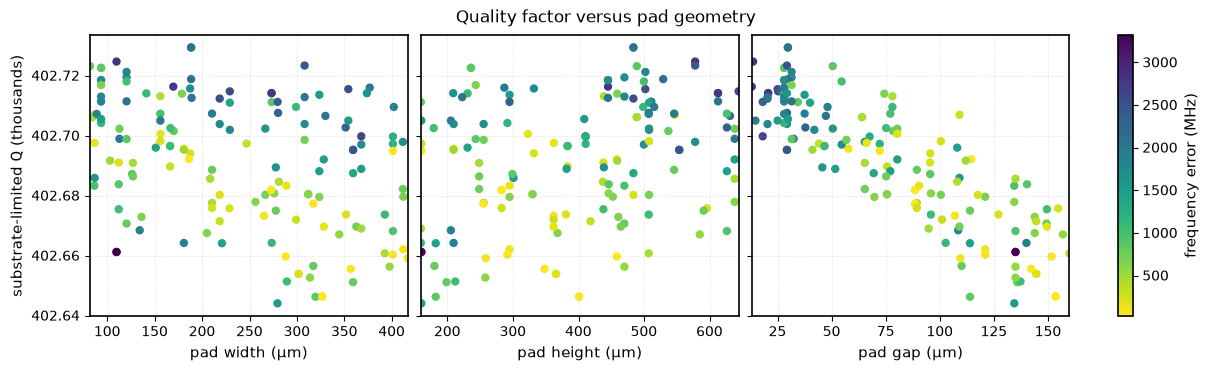

In [10]:
frames = {
    "pad_width": "pad width (µm)",
    "pad_height": "pad height (µm)",
    "pad_gap": "pad gap (µm)",
}
PARAMETERS = list(frames)
target_ghz = F_TARGET / 1e9
frequency_error_mhz = np.abs(trials["f_linear_ghz"] - target_ghz) * 1e3

fig, axes = plt.subplots(1, 3, figsize=(12, 3.6), sharey=True, constrained_layout=True)
for ax, name in zip(axes, PARAMETERS, strict=True):
    points = ax.scatter(
        trials[name],
        trials["quality_factor"] / 1e3,
        c=frequency_error_mhz,
        cmap="viridis_r",
        s=25,
    )
    ax.set_xlabel(frames[name])
axes[0].set_ylabel("substrate-limited $Q$ (thousands)")
fig.colorbar(points, ax=axes, label="frequency error (MHz)")
fig.suptitle("Quality factor versus pad geometry")
plt.show()
plt.close(fig)

### The Pareto frontier

A candidate is dominated when another has no worse frequency error, no lower
$Q$, and no larger pad footprint. The non-dominated candidates form a
three-objective Pareto frontier. Its two projections below show where better
substrate-limited $Q$ costs area or distance from the target frequency.
Because this model omits surface TLS loss, these rankings apply only to the
included silicon and vacuum domains.

2026-09-26 16:01:05.442 | INFO     | __main__:<module>:20 - 20 of 150 trials are on the Pareto frontier


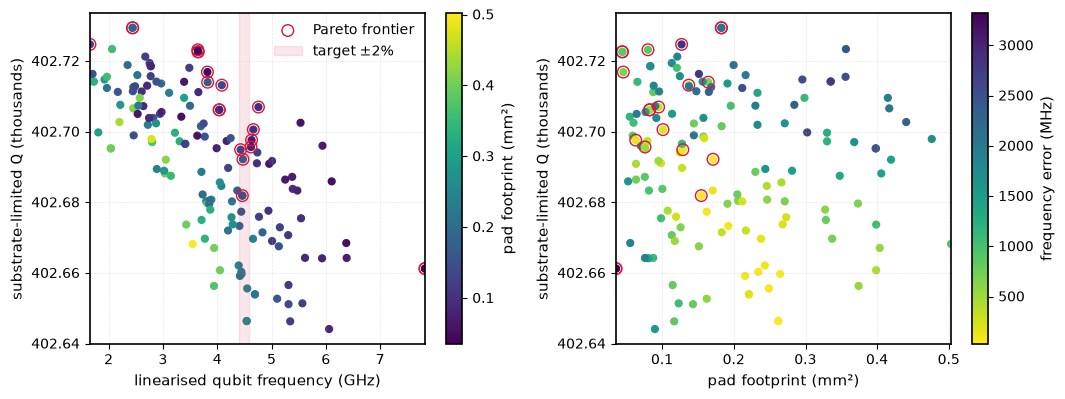

,pad_width,pad_height,pad_gap,f_linear_ghz,quality_factor,footprint_mm2
103,109.62,577.91,13.70,1.656,402724.755,0.127
30,188.31,483.71,29.77,2.442,402729.456,0.182
117,188.31,483.71,29.77,2.442,402729.456,0.182
33,81.59,488.91,50.50,3.642,402723.236,0.080
69,93.32,235.81,28.03,3.648,402722.657,0.044
108,93.32,235.81,28.03,3.648,402722.657,0.044
141,93.32,243.09,31.50,3.820,402716.923,0.045
43,178.62,459.01,74.31,3.824,402714.050,0.164
129,83.98,488.91,64.00,4.037,402706.233,0.082
65,83.98,488.91,64.00,4.037,402706.233,0.082


In [11]:
def pareto_mask(values: np.ndarray) -> np.ndarray:
    """Return a mask of rows not dominated when every column is minimised."""
    keep = np.ones(len(values), dtype=bool)
    for i, candidate in enumerate(values):
        dominated = np.all(values <= candidate, axis=1) & np.any(
            values < candidate, axis=1
        )
        if dominated.any():
            keep[i] = False
    return keep


objective_values = np.column_stack([
    frequency_error_mhz,
    -trials["quality_factor"],
    trials["footprint_mm2"],
])
on_front = pareto_mask(objective_values)
front = trials[on_front].sort_values("f_linear_ghz")
logger.info(f"{len(front)} of {len(trials)} trials are on the Pareto frontier")

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.1))
points = axes[0].scatter(
    trials["f_linear_ghz"],
    trials["quality_factor"] / 1e3,
    c=trials["footprint_mm2"],
    cmap="viridis",
    s=24,
)
axes[0].scatter(
    front["f_linear_ghz"],
    front["quality_factor"] / 1e3,
    facecolors="none",
    edgecolors="crimson",
    s=70,
    label="Pareto frontier",
)
axes[0].axvspan(
    target_ghz * (1 - TOLERANCE_BAND),
    target_ghz * (1 + TOLERANCE_BAND),
    color="crimson",
    alpha=0.1,
    label=f"target ±{TOLERANCE_BAND:.0%}",
)
axes[0].set_xlabel("linearised qubit frequency (GHz)")
axes[0].set_ylabel("substrate-limited $Q$ (thousands)")
axes[0].legend()
fig.colorbar(points, ax=axes[0], label="pad footprint (mm²)")

points = axes[1].scatter(
    trials["footprint_mm2"],
    trials["quality_factor"] / 1e3,
    c=frequency_error_mhz,
    cmap="viridis_r",
    s=24,
)
axes[1].scatter(
    front["footprint_mm2"],
    front["quality_factor"] / 1e3,
    facecolors="none",
    edgecolors="crimson",
    s=70,
)
axes[1].set_xlabel("pad footprint (mm²)")
axes[1].set_ylabel("substrate-limited $Q$ (thousands)")
fig.colorbar(points, ax=axes[1], label="frequency error (MHz)")
fig.tight_layout()
plt.show()
plt.close(fig)

front[
    [
        "pad_width",
        "pad_height",
        "pad_gap",
        "f_linear_ghz",
        "quality_factor",
        "footprint_mm2",
    ]
].round(3)

### Seeing several dimensions at once

Each line is one simulated geometry. Every axis is scaled to the observed
minimum and maximum of that quantity, so a nearly flat physical $Q$ range
remains visible without implying that it varies as much as the pad dimensions.
The colourbar and the table above keep the absolute $Q$ scale in view.

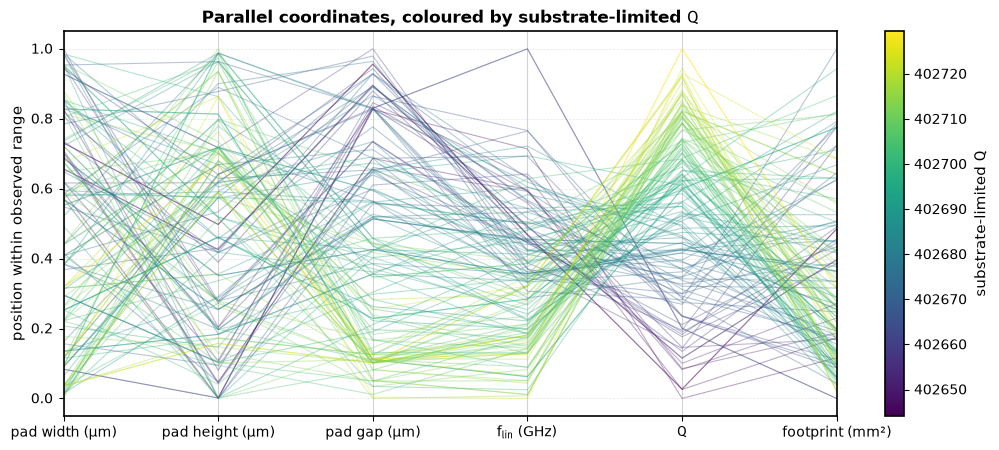

In [12]:
parallel_axes = [*PARAMETERS, "f_linear_ghz", "quality_factor", "footprint_mm2"]
axis_limits = {
    name: (float(trials[name].min()), float(trials[name].max()))
    for name in parallel_axes
}
normaliser = plt.Normalize(
    float(trials["quality_factor"].min()),
    float(trials["quality_factor"].max()),
)
fig, ax = plt.subplots(figsize=(10.5, 4.6))
for row in trials.itertuples():
    values = [
        (getattr(row, name) - axis_limits[name][0])
        / (axis_limits[name][1] - axis_limits[name][0])
        for name in parallel_axes
    ]
    ax.plot(
        range(len(parallel_axes)),
        values,
        color=plt.cm.viridis(normaliser(row.quality_factor)),
        alpha=0.35,
        lw=0.8,
    )
for index in range(len(parallel_axes)):
    ax.axvline(index, color="0.85", lw=0.8, zorder=0)
ax.set_xticks(range(len(parallel_axes)))
ax.set_xticklabels([
    *[frames[name] for name in PARAMETERS],
    "$f_\\mathrm{lin}$ (GHz)",
    "$Q$",
    "footprint (mm²)",
])
ax.set_ylabel("position within observed range")
ax.set_title("Parallel coordinates, coloured by substrate-limited $Q$")
fig.colorbar(
    plt.cm.ScalarMappable(normaliser, plt.cm.viridis),
    ax=ax,
    label="substrate-limited $Q$",
)
fig.tight_layout()
plt.show()
plt.close(fig)

### Frequency and relaxation time

$T_1$ falls as frequency rises even when the quality factor hardly moves:
$T_1\approx Q/(2\pi f_\mathrm{lin})$. The line below uses the median simulated $Q$, while
colour shows each trial's actual $Q$. Departures from the line are the part
due to geometry-dependent field participation rather than the $1/f$ factor.

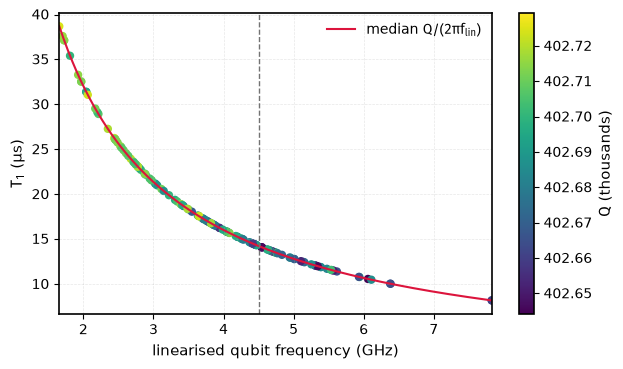

In [13]:
fig, ax = plt.subplots(figsize=(6.4, 3.8))
points = ax.scatter(
    trials["f_linear_ghz"],
    trials["T1_us"],
    c=trials["quality_factor"] / 1e3,
    cmap="viridis",
    s=25,
)
frequencies = np.linspace(
    trials["f_linear_ghz"].min(), trials["f_linear_ghz"].max(), 200
)
median_q = float(trials["quality_factor"].median())
ax.plot(
    frequencies,
    median_q / (2 * np.pi * frequencies * 1e3),
    color="crimson",
    label=r"median $Q/(2\pi f_\mathrm{lin})$",
)
ax.axvline(target_ghz, color="0.45", ls="--", lw=1)
ax.set_xlabel("linearised qubit frequency (GHz)")
ax.set_ylabel("$T_1$ (µs)")
ax.legend()
fig.colorbar(points, ax=ax, label="$Q$ (thousands)")
fig.tight_layout()
plt.show()
plt.close(fig)

### Screened geometry and finer checks

Apply the frequency requirement first. Among trials in that band, keep those
within 1% of its highest substrate-limited $Q$, then choose the smallest pad
footprint. This screens the 0.35 µm sweep; the same candidates then need a
finer mesh before one can be carried forward. The exact ordering inside a
narrow $Q$ band is less trustworthy than the frequency and footprint because
the included loss is nearly flat.

In [14]:
on_target = trials[
    np.abs(trials["f_linear_ghz"] - target_ghz) < TOLERANCE_BAND * target_ghz
]
if on_target.empty:
    logger.warning(
        f"no trial within {TOLERANCE_BAND:.0%} of {target_ghz} GHz; "
        "falling back to the closest trial"
    )
    on_target = trials.loc[[frequency_error_mhz.idxmin()]]
best_q = float(on_target["quality_factor"].max())
affordable = on_target[on_target["quality_factor"] >= best_q * (1 - Q_SLACK)]
screen_best = affordable.loc[affordable["footprint_mm2"].idxmin()]
logger.info(
    f"coarse-screen trial {int(screen_best['trial'])}: pads "
    f"{screen_best['pad_width']:.2f} × {screen_best['pad_height']:.2f} µm, "
    f"gap {screen_best['pad_gap']:.2f} µm"
)
logger.info(
    f"f_lin = {screen_best['f_linear_ghz']:.4f} GHz, "
    f"Q = {screen_best['quality_factor']:.1f}, "
    f"T1 = {screen_best['T1_us']:.2f} µs, "
    f"footprint = {screen_best['footprint_mm2']:.3f} mm²"
)

2026-09-26 16:01:05.837 | INFO     | __main__:<module>:13 - coarse-screen trial 50: pads 401.19 × 160.05 µm, gap 72.20 µm


2026-09-26 16:01:05.837 | INFO     | __main__:<module>:18 - f_lin = 4.4309 GHz, Q = 402694.9, T1 = 14.46 µs, footprint = 0.128 mm²


The 0.35 µm screen is only a first pass. A refined check of candidate
geometries is part of selection because the frequency moves with mesh size.
The values below are separate Palace solves of the same layouts. The
manually retuned 80 × 333 µm layout is within the original parameter bounds;
it is a follow-up geometry, not one of the 150 Optuna trials. Its checks use
the coarse bulk-mesh preset and Palace's linear-solver `MaxIts=10`.

In [15]:
VALIDATION_CSV = """\
trial,mesh_um,f_linear_ghz,p_silicon,raw_eigenmode_q
26,0.25,4.544495156992,0.9197361402568,479553.2631833
50,0.25,4.364294903148,0.9197782482942,377101.3451812
71,0.25,4.401167344547,0.9197691031703,357507.0776671
82,0.25,4.496518950941,0.9197796166443,369784.2170626
134,0.25,4.561388449831,0.9196744932970,376262.8428611
134,0.18,4.493787711289,0.9197159117284,326750.9737928
"""
validation = pd.read_csv(io.StringIO(VALIDATION_CSV)).merge(
    trials[["trial", "pad_width", "pad_height", "pad_gap", "footprint_mm2"]],
    on="trial",
    validate="many_to_one",
)
validation["candidate"] = "trial " + validation["trial"].astype(str)
RETUNED_CSV = """\
mesh_um,f_linear_ghz,p_silicon,raw_eigenmode_q
0.05,4.524674226255,0.9197091788784,402750.0048365
0.035,4.483245144949,0.9196882033502,402662.9841485
0.025,4.456509156151,0.9196762866865,403007.4095914
0.018,4.409857483160,0.9196959697040,402592.8120868
"""
retuned = pd.read_csv(io.StringIO(RETUNED_CSV)).assign(
    candidate="retuned, gap 66.12 µm",
    pad_width=80.0,
    pad_height=333.0,
    pad_gap=66.12,
    footprint_mm2=0.05328,
)
RETUNED_G70_CSV = """\
mesh_um,f_linear_ghz,p_silicon,raw_eigenmode_q
0.025,4.560320565646,0.9197221827958,402724.7846256
0.018,4.533223005171,0.9197078864750,402635.9423255
0.015,4.504008382816,0.9197005754477,402044.8687035
"""
retuned_g70 = pd.read_csv(io.StringIO(RETUNED_G70_CSV)).assign(
    candidate="retuned, gap 70.12 µm",
    pad_width=80.0,
    pad_height=333.0,
    pad_gap=70.12,
    footprint_mm2=0.05328,
)
checks = pd.concat([validation, retuned, retuned_g70], ignore_index=True)
checks["dielectric_q"] = 1 / (checks["p_silicon"] * 2.7e-6)
checks["target_error_mhz"] = (checks["f_linear_ghz"] - target_ghz) * 1e3
checks.sort_values(["mesh_um", "footprint_mm2"])[
    [
        "candidate",
        "mesh_um",
        "f_linear_ghz",
        "target_error_mhz",
        "dielectric_q",
        "footprint_mm2",
    ]
].round(3)

,candidate,mesh_um,f_linear_ghz,target_error_mhz,dielectric_q,footprint_mm2
12,"retuned, gap 70.12 µm",0.015,4.504,4.008,402707.555,0.053
9,"retuned, gap 66.12 µm",0.018,4.410,-90.143,402709.572,0.053
11,"retuned, gap 70.12 µm",0.018,4.533,33.223,402704.354,0.053
8,"retuned, gap 66.12 µm",0.025,4.457,-43.491,402718.191,0.053
10,"retuned, gap 70.12 µm",0.025,4.560,60.321,402698.094,0.053
7,"retuned, gap 66.12 µm",0.035,4.483,-16.755,402712.973,0.053
6,"retuned, gap 66.12 µm",0.050,4.525,24.674,402703.788,0.053
5,trial 134,0.180,4.494,-6.212,402700.840,0.063
4,trial 134,0.250,4.561,61.388,402718.976,0.063
0,trial 26,0.250,4.544,44.495,402691.983,0.076


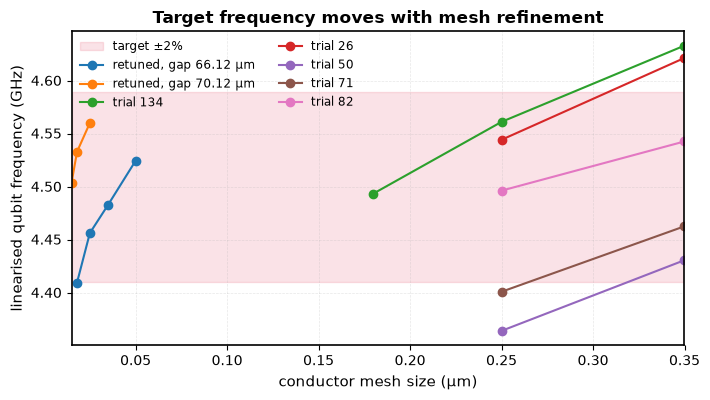

In [16]:
coarse_checks = trials.loc[
    trials["trial"].isin(validation["trial"]), ["trial", "f_linear_ghz"]
].assign(mesh_um=0.35)
coarse_checks["candidate"] = "trial " + coarse_checks["trial"].astype(str)
mesh_checks = pd.concat(
    [coarse_checks, checks[["candidate", "mesh_um", "f_linear_ghz"]]],
    ignore_index=True,
)
fig, ax = plt.subplots(figsize=(7.2, 4.1))
ax.axhspan(
    target_ghz * (1 - TOLERANCE_BAND),
    target_ghz * (1 + TOLERANCE_BAND),
    color="crimson",
    alpha=0.12,
    label=f"target ±{TOLERANCE_BAND:.0%}",
)
for candidate, group in mesh_checks.groupby("candidate"):
    ordered = group.sort_values("mesh_um")
    ax.plot(ordered["mesh_um"], ordered["f_linear_ghz"], "o-", label=candidate)
ax.set_xlabel("conductor mesh size (µm)")
ax.set_ylabel("linearised qubit frequency (GHz)")
ax.set_title("Target frequency moves with mesh refinement")
ax.legend(ncol=2, fontsize="small")
fig.tight_layout()
plt.show()
plt.close(fig)

Selection uses 0.025 µm as the mesh floor and requires every available
finer check of a candidate to remain within ±2% of 4.5 GHz. The 0.018 and
0.015 µm points are sensitivity checks, not a routine resource target.
This is a mesh check, not an extrapolation to zero mesh size; the frequency
shift still needs reporting alongside the chosen geometry.
Trial 134 moves from 4.6333 GHz at 0.35 µm to 4.5614 GHz at 0.25 µm and
4.4938 GHz at 0.18 µm. The last step is still 1.5%, so 4.4938 GHz is a
finest-mesh estimate for this study rather than a converged limit.
The retuned 80 × 333 µm layout moves from 4.5247 GHz at 0.05 µm to 4.4099 GHz
at 0.018 µm. The 0.025-to-0.018 µm step shifts the frequency by 1.05%, while
its participation-derived dielectric $Q$ changes by 0.0021%. At the finest
mesh the layout misses the lower target-band edge by 0.14 MHz. This shows why
the coarse-screen winner needs a same-geometry mesh check before selection.
At 0.05 µm, changing only the bulk-mesh preset from coarse to default gives
4.524609 GHz and silicon participation 0.919742, versus 4.524674 GHz and
0.919709. The 0.065 MHz frequency difference is much smaller than the
near-conductor refinement shift; dielectric $Q$ differs by 0.0035%.
Increasing only the pad gap to 70.12 µm keeps the retuned layout inside the
target band from 0.025 µm (4.5603 GHz) to 0.015 µm (4.5040 GHz). The
0.025-to-0.018 µm frequency
shift is 27.10 MHz (0.59%), and the 0.018-to-0.015 µm shift is 29.21 MHz
(0.64%). The latter did not shrink despite a smaller mesh step, so the
frequency is not yet mesh converged. The participation-derived dielectric
$Q$ changes by only 0.0023% from 0.025 to 0.015 µm. The 0.025 µm solve
peaked at 423 GB total; the 0.015 µm check used 1.4 TB total across 16
regular Triton nodes. The cheaper mesh is enough for this ±2% selection,
while the 56 MHz frequency drift remains a limit on its precision.

In [17]:
SELECTION_MESH_UM = 0.025
selection_checks = checks[checks["mesh_um"] >= SELECTION_MESH_UM]
selected_resolution = selection_checks.loc[
    selection_checks.groupby("candidate")["mesh_um"].idxmin()
]
band_mhz = TOLERANCE_BAND * target_ghz * 1e3
stays_in_band = checks.groupby("candidate")["target_error_mhz"].apply(
    lambda errors: errors.abs().lt(band_mhz).all()
)
verified_on_target = selected_resolution[
    selected_resolution["candidate"].isin(stays_in_band[stays_in_band].index)
]
assert not verified_on_target.empty, "no candidate stays in the target band"
best_q = float(verified_on_target["dielectric_q"].max())
affordable = verified_on_target[
    verified_on_target["dielectric_q"] >= best_q * (1 - Q_SLACK)
]
best = affordable.loc[affordable["footprint_mm2"].idxmin()]
best_layout = Layout(
    pad_width=float(best["pad_width"]),
    pad_height=float(best["pad_height"]),
    pad_gap=float(best["pad_gap"]),
)
logger.info(
    f"selected at working mesh {best['candidate']}: {best_layout}, "
    f"f_lin = {best['f_linear_ghz']:.4f} GHz at {best['mesh_um']:.3f} µm, "
    f"substrate Q = {best['dielectric_q']:.1f}, "
    f"footprint = {best['footprint_mm2']:.3f} mm²"
)
best_layout

2026-09-26 16:01:05.941 | INFO     | __main__:<module>:24 - selected at working mesh retuned, gap 70.12 µm: Layout(pad_width=80.0, pad_height=333.0, pad_gap=70.12), f_lin = 4.5603 GHz at 0.025 µm, substrate Q = 402698.1, footprint = 0.053 mm²


Layout(pad_width=80.0, pad_height=333.0, pad_gap=70.12)

### Electric-energy participation

The silicon share of electric energy sets this model's loss budget because
vacuum has zero loss tangent. The left plot shows the change in silicon
participation relative to its median in parts per million; the right keeps
the absolute participation scale and compares dielectric $Q$ with
$Q=1/(p_\mathrm{Si}\tan\delta_\mathrm{Si})$.

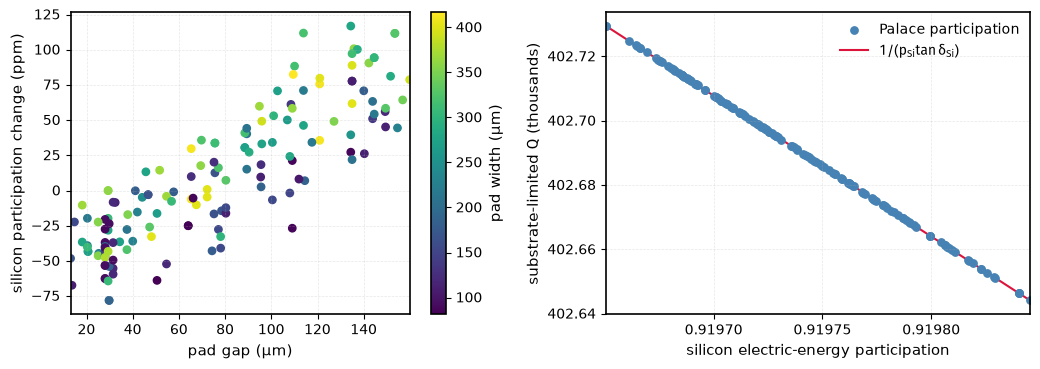

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 3.8))
silicon_p = trials["participation_domain1"]
points = axes[0].scatter(
    trials["pad_gap"],
    (silicon_p - silicon_p.median()) * 1e6,
    c=trials["pad_width"],
    cmap="viridis",
    s=28,
)
axes[0].set_xlabel("pad gap (µm)")
axes[0].set_ylabel("silicon participation change (ppm)")
fig.colorbar(points, ax=axes[0], label="pad width (µm)")
axes[1].scatter(
    silicon_p,
    trials["quality_factor"] / 1e3,
    color="steelblue",
    s=28,
    label="Palace participation",
)
p_grid = np.linspace(float(silicon_p.min()), float(silicon_p.max()), 200)
axes[1].plot(
    p_grid,
    1 / (p_grid * 2.7e-6 * 1e3),
    color="crimson",
    zorder=0,
    label=r"$1/(p_{\mathrm{Si}}\tan\delta_{\mathrm{Si}})$",
)
axes[1].set_xlabel("silicon electric-energy participation")
axes[1].set_ylabel("substrate-limited $Q$ (thousands)")
axes[1].xaxis.set_major_locator(plt.MaxNLocator(4))
axes[1].xaxis.set_major_formatter(plt.FormatStrFormatter("%.5f"))
axes[1].legend()
fig.tight_layout()
plt.show()
plt.close(fig)

The raw eigenmode $Q$ is a solver diagnostic, not the loss objective. For the
same 82 × 362.34 µm pads on a 0.12 µm mesh, raising Palace's linear-solver
MaxIts from 1 to 3 changes frequency by only 0.048 MHz and silicon
participation by less than $5\times10^{-11}$, but changes raw $Q$ from
$1.9\times10^7$ to $4.03\times10^5$. The participation-derived $Q$ stays
near $4.03\times10^5$.

(slurm-launcher)=
## Running the study on a Slurm cluster

On a shared cluster the work goes out as **one job per trial**, which is what
`qpdk.simulation.SlurmCluster` renders: an `sbatch` script taking a parameter
file as its argument, submitted once per trial. Each job asks for
`solver_cores` MPI ranks spread over `trial_nodes` nodes, with
`mem_per_task` memory on each node. The driver keeps `MAX_IN_FLIGHT` jobs
alive and replaces each as it finishes.

The alternative, hosting a Ray cluster inside one multi-node allocation, is
rendered by the same object and is a better fit when the job owns its nodes
rather than sharing them; the manual `ray start` arrangement it uses is the
one from the
[Ray on Slurm guide](https://docs.ray.io/en/latest/cluster/vms/user-guides/community/slurm.html).

Two kinds of job are involved, and it is worth keeping them straight:

- the **driver**, a one-core job that asks Optuna for trials, submits them,
  and tells Optuna what comes back. It runs this notebook and owns the study,
  so it is the job whose log tells you how the sweep is going.
- the **trial jobs**, one per geometry, where the solving actually happens.
  Each writes its own log under `log_dir`.

Submitting the driver as a job rather than running it interactively matters for
anything long: a study that takes hours should not be tied to a login session.

The values above are placeholders, and the comments say what each one has to
satisfy rather than which cluster it came from. Point them at a real site
without editing the notebook by setting the matching `QPDK_*` variables
(`QPDK_PARTITION`, `QPDK_SCRATCH`, `QPDK_SIF`, `QPDK_SETUP`,
`QPDK_SOLVER_CORES`, `QPDK_TRIAL_NODES`, `QPDK_MEM_PER_TASK`,
`QPDK_TIME_LIMIT`) before running
it; `site()` reads them and falls back to the placeholder.

In [19]:
driver = (
    f"export QPDK_RUN_OPTIMIZATION=1 "
    f"QPDK_N_TRIALS={N_TRIALS} QPDK_MAX_IN_FLIGHT={MAX_IN_FLIGHT} "
    f"QPDK_PALACE_SIF={PALACE_SIF} QPDK_TRIALS_CSV=trials.csv\n"
    "uv run --frozen python notebooks/src/palace_batched_qubit_optimization.py"
)

driver_path = cluster.write_driver_script("build/submit_driver.sbatch", driver)
logger.info(f"wrote {driver_path}")
print(driver_path.read_text())

2026-09-26 16:01:06.059 | INFO     | __main__:<module>:9 - wrote build/submit_driver.sbatch


#!/bin/bash
#SBATCH --job-name=qpdk-opt-driver
#SBATCH --partition=batch
#SBATCH --nodes=1
#SBATCH --ntasks=1
#SBATCH --cpus-per-task=1
#SBATCH --mem=2G
#SBATCH --time=24:00:00
#SBATCH --output=/Users/nikosavola/.worktrees/quantum-rf-pdk/palace-optimization-resource/notebooks/slurm-logs/qpdk-opt-driver-%j.out

set -euo pipefail
# Slurm runs a spool copy of the batch script, so $0 is not the submit
# directory. It sets SLURM_SUBMIT_DIR for jobs submitted from a login node but
# not always for ones submitted from a compute node, and a plain `cd ""` would
# quietly leave the job in $HOME, so fall back to where it already is. Commands
# passed in should use absolute paths all the same.
cd "${SLURM_SUBMIT_DIR:-$PWD}"

# Exported before the setup snippet, which may expand it; `set -u` would
# otherwise abort the job here.
export QPDK_SCRATCH="/scratch/$USER/palace-optimization"
export MPLBACKEND=Agg


module load python 2>/dev/null || true
export UV_CACHE_DIR="$QPDK_SCRATCH/uv-cache"
export 

The Ray arrangement is the same object rendering a different script: one
allocation, a Ray head and workers started across its nodes, and the driver on
the head selecting `ray_executor`. It suits a job that owns its nodes; the
one-job-per-trial path above suits a shared cluster, because the jobs queue
independently.

In [20]:
ray_driver = (
    f"export QPDK_RUN_OPTIMIZATION=1 QPDK_EXECUTOR=ray "
    f"QPDK_N_TRIALS={N_TRIALS} QPDK_MAX_IN_FLIGHT={MAX_IN_FLIGHT} "
    f"QPDK_PALACE_SIF={PALACE_SIF} QPDK_TRIALS_CSV=trials.csv\n"
    "uv run --frozen python notebooks/src/palace_batched_qubit_optimization.py"
)
ray_path = cluster.write_sbatch_script("build/submit_ray.sbatch", ray_driver)
logger.info(f"wrote {ray_path}")

2026-09-26 16:01:06.064 | INFO     | __main__:<module>:8 - wrote build/submit_ray.sbatch


Submitting is then `sbatch build/submit_driver.sbatch`, and from there the
driver's log is the one to watch: it reports each trial as it lands, how many
back, how many failed, and the best design so far. Because the driver writes
its log as it goes rather than at the end, `tail -f` on it is enough to follow
a study that runs for hours.

```bash
sbatch build/submit_driver.sbatch
tail -f slurm-logs/$QPDK_JOB_NAME-driver-*.out   # qpdk-opt-driver-*.out by default
```

Two things are worth checking before a long run:

- **Reproduce a known result first.** Submit one or two trials and
  compare them against the same geometry solved elsewhere, or against the
  inductance-scaling check above. A different MPI build, BLAS, or node
  instruction set can perturb a solve in ways that look like findings.
- **Size time and memory from a measured trial.** The cost rises steeply with
  mesh refinement and mode count; the saved fine checks use multi-node MPI
  jobs because they exceed a comfortable single-node memory request. A job
  that runs out of time writes nothing. `solver_cores` and `MAX_IN_FLIGHT`
  set how many ranks a trial uses and how many trials run at once.

## Summary

- Each Palace eigenmode solve supplies the linearised qubit frequency and
  substrate-limited quality factor. The pad dimensions supply the footprint.
  Optuna keeps frequency error, $Q$, and footprint as separate objectives.
- The geometry plots and parallel coordinates show how those objectives move
  across the sampled pad sizes and gaps. The Pareto front keeps the useful
  tradeoffs visible without collapsing them into one score.
- $T_1=Q/(2\pi f_\mathrm{lin})$ is a derived result, so the fall with frequency in
  the $T_1$ plot is expected even at nearly constant $Q$. The silicon energy
  participation provides a separate check on the simulated loss budget.
- These $Q$ values include the modelled bulk silicon loss. The thin
  interfaces that can dominate hardware TLS loss are not resolved here, so
  neither $Q$ nor $T_1$ is an absolute device prediction.
- Each Slurm trial requests two nodes but only four ranks and 32 GB on each.
  A fixed number in flight lets the driver replace completed trials without
  waiting for the slowest member of a batch.

## References

```{bibliography}
:filter: docname in docnames
```